In [1]:
#Import Library
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from scipy import stats # These are the libraries used in my analysis 


In [2]:
# Load CSV file
df = pd.read_csv('../data/DA task.csv', encoding='latin1')

In [3]:
df.head()

,ORGANIZATION_ID,ACTIVITY_NAME,TIMESTAMP,CONVERTED,CONVERTED_AT,TRIAL_START,TRIAL_END
0,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:03:53.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
1,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:04:52.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
2,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:04:53.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
3,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:05:18.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
4,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:06:00.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000


In [4]:
df.shape

(170526, 7)

Data Cleaning Process

In [5]:
date_cols = ["TIMESTAMP", "CONVERTED_AT", "TRIAL_START", "TRIAL_END"]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

#The above code converts all 4 date columns from text into real dates so we can do date calculations.
#If any value can't be converted it becomes blank (NaT) instead of crashing.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170526 entries, 0 to 170525
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   ORGANIZATION_ID  170526 non-null  object        
 1   ACTIVITY_NAME    170526 non-null  object        
 2   TIMESTAMP        170526 non-null  datetime64[ns]
 3   CONVERTED        170526 non-null  bool          
 4   CONVERTED_AT     34235 non-null   datetime64[ns]
 5   TRIAL_START      170526 non-null  datetime64[ns]
 6   TRIAL_END        170526 non-null  datetime64[ns]
dtypes: bool(1), datetime64[ns](4), object(2)
memory usage: 8.0+ MB


In [7]:
#Removing extra space and organizing our data
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('-', '_')
df.columns

# I just did this for better readability

Index(['organization_id', 'activity_name', 'timestamp', 'converted',
       'converted_at', 'trial_start', 'trial_end'],
      dtype='object')

In [8]:
# Check missing values
print(df.isna().sum())

organization_id         0
activity_name           0
timestamp               0
converted               0
converted_at       136291
trial_start             0
trial_end               0
dtype: int64


In [9]:
#Removing Duplicates
before = len(df) # We count the number of rows

In [10]:
df = df.drop_duplicates().reset_index(drop=True).copy()

In [11]:
after = len(df) # We count the number of rows again

In [12]:
print(f"Duplicates removed: {before - after: ,}")

Duplicates removed:  67,631


In [13]:
print(f"Clean shape: {df.shape}")

Clean shape: (102895, 7)


What was done in the above cells was basically to clean our data Counts total rows, removes exact duplicate rows then counts again to see how many were removed. `.reset_index()` reorders row numbers cleanly, and `.copy()` creates a separate fresh dataset.

Feature Engineering

In [14]:
df["days_into_trial"] = (df['timestamp'] - df['trial_start']).dt.days

For every row the above code calculates how many days into the trial that event happened. If an event happened on Day 3 of the trial, days_into_trial = 3. This is done by subtracting the trial start date from the event timestamp. Then i now have a new column called days_into_trial.

In [15]:
df["within_trial"] = (
    (df["timestamp"] >= df["trial_start"]) 
    & (df["timestamp"] <=df["trial_end"])
)

Generates a boolean column for each row indicating whether the event falls inside the 30-day trial period. A value of True shows the event occurred during the trial window, while False indicates it happened either before the trial began or after it ended.

This adds a new column named within_trial.

In [16]:
out_of_Windows = df[~df["within_trial"]]
print(f"Out of trail events: {len(out_of_Windows):,}")

Out of trail events: 0



The above line of code selects only the rows that occurred outside the trial window and counts them. The ~ operator represents NOT, so it filters for rows where within_trial is False

In [17]:
df_clean = df[df["within_trial"]].copy()
print(f"Final clean shape (in_windows only) : {df_clean.shape}")

Final clean shape (in_windows only) : (102895, 9)



This produces the final cleaned dataset by filtering to only include events that occurred during the trial period. All subsequent analysis is based on df_clean.

In [18]:
print(f"Unique_orgs: {df_clean['organization_id'].nunique():,}")
print(f"Converted_orgs: {df_clean[df_clean['converted']==True]['organization_id'].nunique():,}")
print(f"Non-converted_orgs: {df_clean[df_clean['converted']==False]['organization_id'].nunique():,}")
print(f"\n Data range of events: {df_clean['timestamp'].min()} → {df_clean['timestamp'].max()}")


Unique_orgs: 966
Converted_orgs: 206
Non-converted_orgs: 760

 Data range of events: 2024-01-01 20:52:26 → 2024-04-28 15:10:31


This highlights the final validation checks by identifying the number of unique organizations in the cleaned dataset, counting how many converted versus those that did not, and verifying the overall event date range.

After cleaning the dataset, building a organisation level table follows next, this collapses 102,895 event rows into 966 rows i.e. one row per organisation. Think of it as turning a detailed attendance register into a report card for each student.

In [19]:
# Building Org-Level Summary Table

# But first we need to Count How Many Times Each Org Did An Activity

activity_counts = (
    df_clean.groupby(["organization_id", "activity_name"])
    .size()
    .unstack(fill_value=0)

)

Aggregates the data by organization and activity, counting how often each organization performed each activity. 

This results in a table where each row represents one organization and each column represents an activity.

In [20]:
# I will proceed to build the core organization level metrics

org_stats = (
    df_clean.groupby("organization_id")
    .agg(
        converted = ("converted", "first"),
        converted_at = ("converted_at", "first"),
        trial_start = ("trial_start", "first"),
        trial_end = ("trial_end", "first"),
        total_events = ("activity_name", "count"),
        unique_activities = ("activity_name", "nunique"),
        days_active = ("days_into_trial", "nunique"),
        first_event_day = ("days_into_trial", "min"),
        last_events_day = ("days_into_trial", "max"),
    )
)  

In [21]:
print(org_stats)

                                  converted        converted_at  \
organization_id                                                   
0040dd9ab132b92d5d04bc3acf14d2e2      False                 NaT   
00456fd86311b6095ad05f7e31758f0d      False                 NaT   
007d48a2bc006e6eac0348c788d26dfd      False                 NaT   
00d6461845d0042b929379c263e9edef      False                 NaT   
00d812389a3cffdbf014ba194cbe922e      False                 NaT   
...                                     ...                 ...   
4e44f506184abb41230dca9183e0dfde       True 2024-02-03 15:12:28   
4e76bb8e72c66ac1020407778635938f      False                 NaT   
4e7e4c7bd153b3e8728e7be9e717071b      False                 NaT   
4e900f739ad1a3cc11c0bc2ad85db6ff      False                 NaT   
4eb736e6ff7851d301ae68a6aa37081a      False                 NaT   

                                         trial_start           trial_end  \
organization_id                                     

For each organization, calculates 9 key summary metrics:

converted — whether the organization converted (Yes or No)

converted_at — the date of conversion

trial_start / trial_end — the start and end dates of the trial

total_events — total number of actions performed

unique_activities — number of distinct activities engaged in

days_active — number of days with any recorded activity

first_event_day — how soon activity began after the trial started

last_event_day — how far into the trial they remained active

In [22]:
org_df = org_stats.join(activity_counts)

#  Combines the two tables: the summary stats and the activity counts side by side into one single table called org_df.

In [23]:
org_df["module_used"] = (
    (org_df.get("Scheduling.Shift.Created", 0) > 0).astype(int) +
    (org_df.get("PunchClock.PunchedIn", 0) > 0).astype(int) +
    (org_df.get("Absence.Request.Created", 0) > 0).astype(int) +
    (org_df.get("Timesheets.BulkApprove.Confirmed", 0) > 0).astype(int) +
    (org_df.get("Communication.Message.Created", 0) > 0).astype(int) 
)

The above line of code creates a score from 0 to 5 showing how many of the 5 core platform modules each organisation actually used. Each module contributes 1 if used at least once, 0 if never used. A new modules_used column is then created

In [24]:
print(f" Org-level summary Table : {org_df.shape}")
org_df.head(5)

 Org-level summary Table : (966, 38)


,converted,converted_at,trial_start,trial_end,total_events,unique_activities,days_active,first_event_day,last_events_day,Absence.Request.Approved,...,Scheduling.Shift.Created,Scheduling.ShiftHandover.Accepted,Scheduling.ShiftHandover.Created,Scheduling.ShiftSwap.Accepted,Scheduling.ShiftSwap.Created,Scheduling.Template.ApplyModal.Applied,Shift.View.Opened,ShiftDetails.View.Opened,Timesheets.BulkApprove.Confirmed,module_used
organization_id,,,,,,,,,,,,,,,,,,,,,
0040dd9ab132b92d5d04bc3acf14d2e2,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39,1004,14,11,0,29,3,...,576,0,0,0,0,10,0,1,0,4
00456fd86311b6095ad05f7e31758f0d,False,NaT,2024-01-11 13:44:36,2024-02-10 13:44:36,6,4,1,0,0,0,...,1,0,0,0,0,0,0,0,0,2
007d48a2bc006e6eac0348c788d26dfd,False,NaT,2024-03-16 22:58:07,2024-04-15 22:58:07,5,2,2,0,1,0,...,0,0,0,0,0,0,0,0,0,1
00d6461845d0042b929379c263e9edef,False,NaT,2024-03-05 02:57:05,2024-04-04 02:57:05,2,2,1,8,8,0,...,1,0,0,0,0,0,0,0,0,2
00d812389a3cffdbf014ba194cbe922e,False,NaT,2024-03-13 22:13:10,2024-04-12 22:13:10,586,6,21,0,29,0,...,157,0,0,0,0,0,0,0,0,3


CONVERSION DRIVER ANALYSIS

Compares converted and non-converted organisations to find which behaviours and activities are linked to conversion.

In [25]:

# Split Organisation  Into Two Groups (Converted and Non Converted)

converted = org_df[org_df["converted"]==True]
non_converted = org_df[org_df["converted"]==False]

In [26]:
print(f"Converted Orgs: {len(converted):,}")
print(f"Non Converted Orgs: {len(non_converted):,}")
print(f"Conversion Ratio: {len(converted)/len(org_df):.2%}")

Converted Orgs: 206
Non Converted Orgs: 760
Conversion Ratio: 21.33%


About 1 in 5 organisations converted, matching what the problem statement told us.

In [27]:
metrics = ["total_events", "unique_activities", "days_active", 
           "first_event_day", "last_events_day", "module_used"]

comparison = org_df.groupby("converted")[metrics].median()
print(comparison)

           total_events  unique_activities  days_active  first_event_day  \
converted                                                                  
False               8.0                2.0          1.0              0.0   
True                8.0                2.0          1.0              0.0   

           last_events_day  module_used  
converted                                
False                  0.0          1.0  
True                   0.0          1.0  


What the above code does is that it calculates the median value of each engagement metric separately for converted and non-converted organisation. We use median instead of average because a few very active organisation could distort the average

Then shows median values for each metric across both groups. The numbers were very similar between the two groups.

The first hint that general engagement doesn't predict conversion.

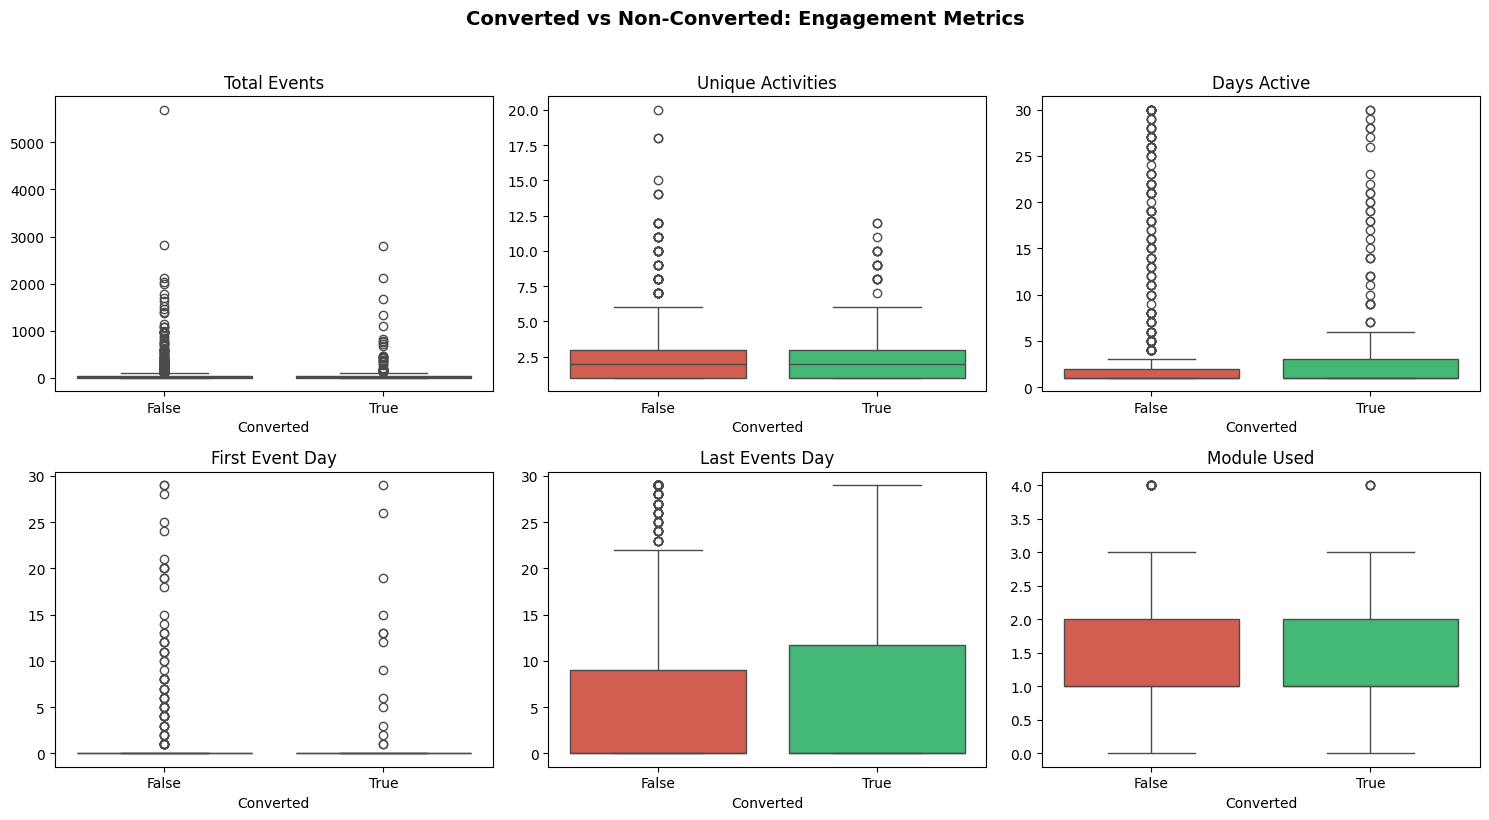

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, metric in enumerate(metrics):

    sns.boxplot(
        data=org_df, 
        x="converted", 
        y=metric, 
        ax=axes[i],
        hue="converted",
        palette={True: "#2ecc71", False: "#e74c3c"},
        legend=False
    )

    axes[i].set_title(metric.replace("_", " ").title())
    axes[i].set_xlabel("Converted")
    axes[i].set_ylabel("")

    plt.suptitle("Converted vs Non-Converted: Engagement Metrics", 
             fontsize=14, fontweight="bold", y=1.02)
    
plt.tight_layout()
plt.savefig("engagement_comparison.png", bbox_inches="tight", dpi=150)
plt.show()

# This creates 6 box plots, one for each engagement metric, comparing converted (green) vs non-converted (red) organisations. 

What Each Box Plot Was Telling Us Total Events — Red and green boxes at same height

Converted orgs didn't do more actions than non-converted orgs

Unique Activities — Red and green boxes at same height

Converted orgs didn't try more different features

Days Active — Green boxes is a little bit higher

Converted orgs were a little active on more days — but the difference was too small to be statistically meaningful

First Event Day — Red and green boxes at same height

Converted orgs didn't start faster after trial began

Last Event Day — Green box slightly higher

Converted orgs stayed active slightly longer

Modules Used — Red and green boxes at same height

Converted orgs didn't use more modules

The overall message from all 6 charts:

Converted and non-converted orgs look almost identical in their general behaviour. You cannot tell them apart just by looking at how much they used the platform.

In [29]:
print("\n --- Mann-Whitney U Test (p-values < 0.05 = real difference) ---")
for metric in metrics:
    group1 = converted[metric].dropna()
    group2 = non_converted[metric].dropna()
    stat, p = stats.mannwhitneyu(
        group1, 
        group2, 
        alternative="two-sided"
    )
    significance = "✅ SIGNIFICANT" if p < 0.05 else "❌ not significant"
    print(f"{metric:<25} p={p:.4f} {significance}")

    


 --- Mann-Whitney U Test (p-values < 0.05 = real difference) ---
total_events              p=0.8513 ❌ not significant
unique_activities         p=0.6502 ❌ not significant
days_active               p=0.7330 ❌ not significant
first_event_day           p=0.2977 ❌ not significant
last_events_day           p=0.8772 ❌ not significant
module_used               p=0.8604 ❌ not significant


The Mann-Whitney U test was selected because engagement metrics were highly skewed and contained extreme outliers, making non-parametric testing more appropriate than traditional t-tests.

In [30]:
# Activity-level conversion rates 

activity_cols = [col for col in org_df.columns 
                 if any(col.startswith(x) for x in [
                    "Scheduling", "PunchClock", "Absence", 
                    "Timesheets", "Communication", "Mobile",
                    "Shift", "Break", "Revenue", "Integration" ])
                ]

conversion_rates = []
for col in activity_cols:
    users = org_df[org_df[col] > 0]
    if len(users) > 0:
        rate = round(users["converted"].mean() * 100, 1)
        count = len(users)
        conversion_rates.append({"activity" : col, 
                                   "conversion_rate" : rate, 
                                   "orgs_used_it" : count})
        
activity_conv_df = (pd.DataFrame(conversion_rates)
                     .sort_values("conversion_rate", ascending=False))

activity_conv_df["conversion_rate"] = activity_conv_df["conversion_rate"].apply(lambda x: f"{x}%")
print("\n --- Conversion Rates by Activity (orgs that used it vs didn't) ---")
print(activity_conv_df.to_string(index=False))


 --- Conversion Rates by Activity (orgs that used it vs didn't) ---
                              activity conversion_rate  orgs_used_it
      Scheduling.ShiftHandover.Created           36.4%            11
     Scheduling.ShiftHandover.Accepted           33.3%             9
   Scheduling.OpenShiftRequest.Created           30.2%            43
              Absence.Request.Rejected           28.6%            14
Scheduling.Template.ApplyModal.Applied           25.0%           108
                  PunchClock.PunchedIn           22.7%           211
           Scheduling.Availability.Set           22.0%            59
             Scheduling.Shift.Approved           22.0%           200
              Scheduling.Shift.Created           21.8%           848
    Scheduling.Shift.AssignmentChanged           21.6%           343
                Mobile.Schedule.Loaded           21.3%           456
               Absence.Request.Created           20.5%            39
              ShiftDetails.View.Op

For each activity, filters to only organisations that used it and calculates what percentage of them converted. I Only includes activities used by at least 10 organisations to avoid misleading percentages from tiny samples. Sorted from highest to lowest conversion rate.

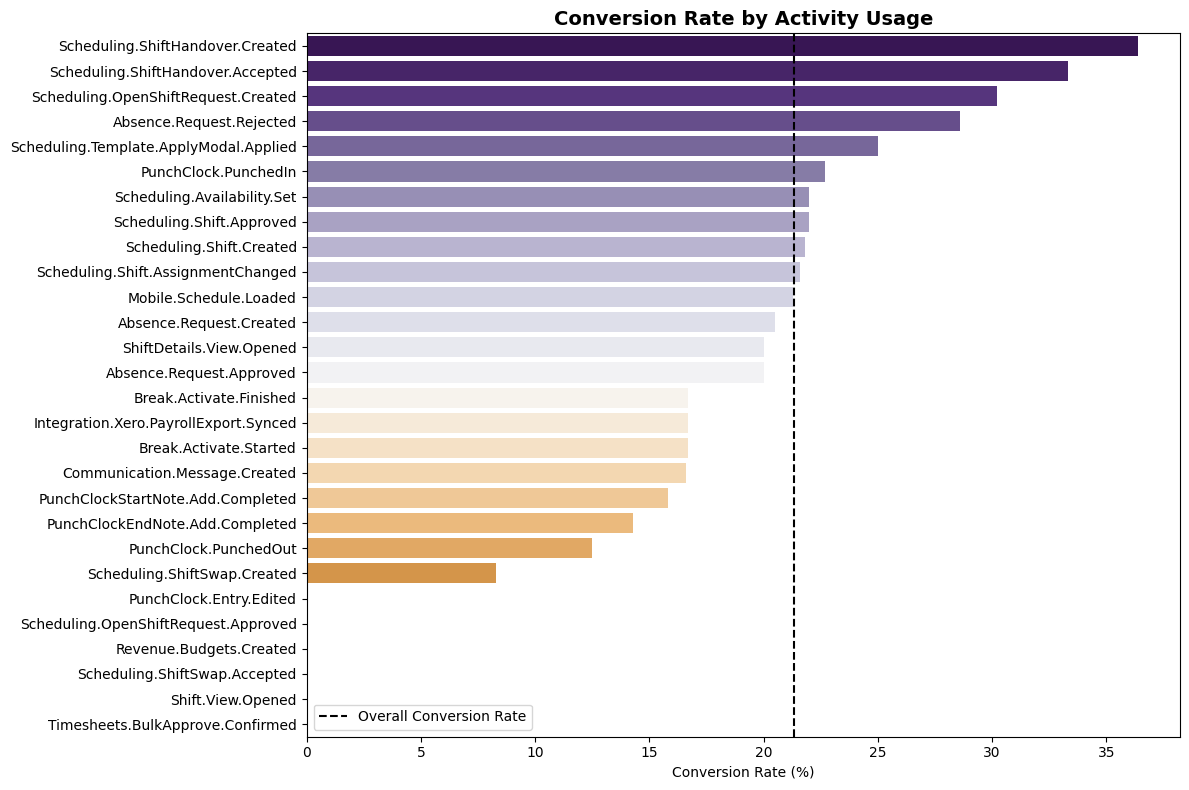

Chart Saved


In [ ]:
activity_conv_df["conversion_rate_num"] = activity_conv_df["conversion_rate"].str.replace("%", "").astype(float)

plt.figure(figsize=(12, 8))
sns.barplot(
    data=activity_conv_df,
    y="activity",
    x="conversion_rate_num",
    hue="activity",
    palette= "PuOr_r",
    legend=False
)

plt.axvline(x=len(converted)/len(org_df)*100, color="black", 
            linestyle="--", label="Overall Conversion Rate")
plt.title("Conversion Rate by Activity Usage", fontsize=14, fontweight="bold")
plt.xlabel("Conversion Rate (%)")
plt.ylabel("")
plt.legend()
plt.tight_layout()
plt.savefig("conversion_by_activity.png", bbox_inches="tight", dpi=150)
plt.show()
print("Chart Saved")

#This creates a horizontal bar chart showing the conversion rate for each activity. 
#A dashed vertical line marks the overall 21.3% baseline. Activities with bars extending past the line are positive signals for conversion.

A small number of activities, ShiftHandover, OpenShiftRequest, Template usage, PunchClock etc are associated with conversion rates above the 21.3% baseline. These became the foundation for a Trial Goal definitions.

[ True False]
